<a href="https://colab.research.google.com/github/kondratyukkatya9-ML/ML_home_work/blob/main/Kaggle_HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [ ]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix




In [ ]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-5/data'

In [ ]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: katerynakondratyuk
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 44.8MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-5/bank-customer-churn-prediction-dlu-course-c-5.zip to ./bank-customer-churn-prediction-dlu-course-c-5


In [ ]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-5'
os.listdir(data_dir)


['train.csv', 'sample_submission.csv', 'test.csv']

Area under ROC score on Train dataset: 0.88


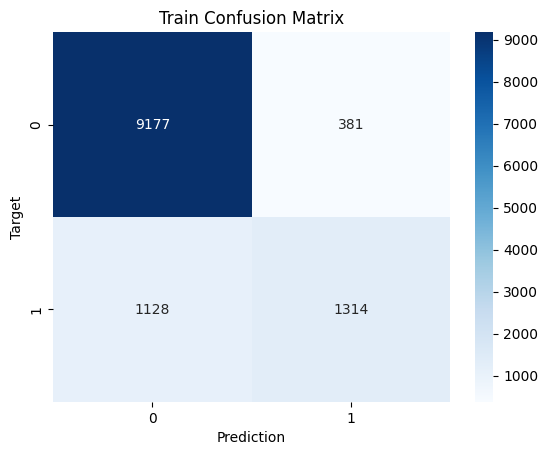

Area under ROC score on Validation dataset: 0.88


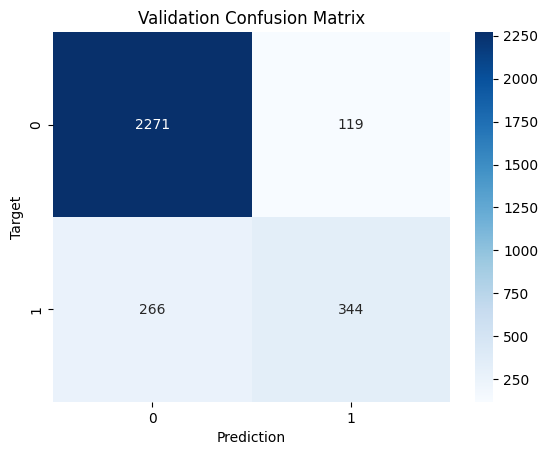

['churn_model.joblib']

In [ ]:
raw_df = pd.read_csv(data_dir + '/train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, stratify=raw_df['Exited'], random_state=42)

# Створюємо трен. і вал. набори
input_cols = ['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']
target_col = 'Exited'
train_inputs, train_target = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_target = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_target)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, fmt='d', annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_target, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_target, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'churn_model.joblib')



**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train dataset: 0.91


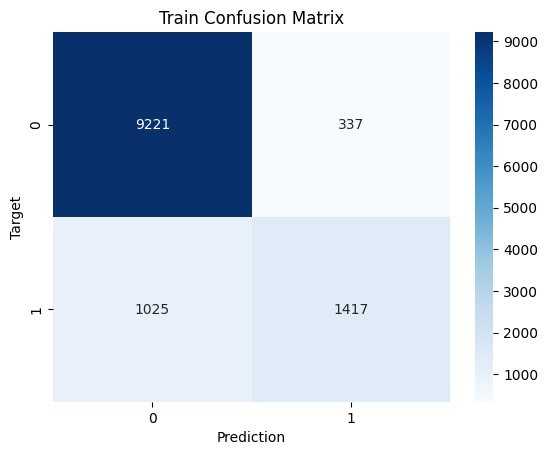

Area under ROC score on Validation dataset: 0.91


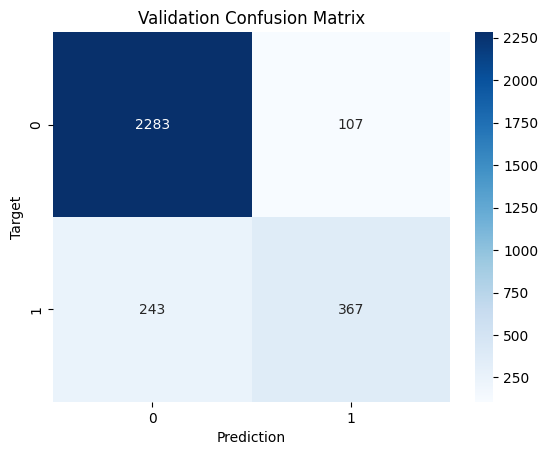

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
numerical_transformer_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', MinMaxScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
])
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor_poly', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])
model_pipeline_poly.fit(train_inputs, train_target)
train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_target, 'Train')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_target, 'Validation')





Так, модель генералізує краще, вона не overfit,  не underfit, оскільки різниці між метриками на test  і validation майже нема.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.93


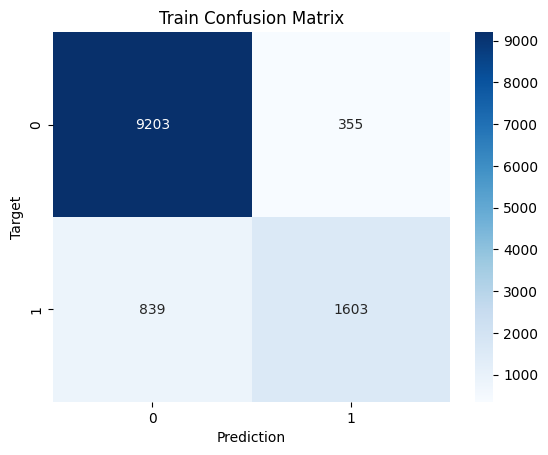

Area under ROC score on Validation dataset: 0.93


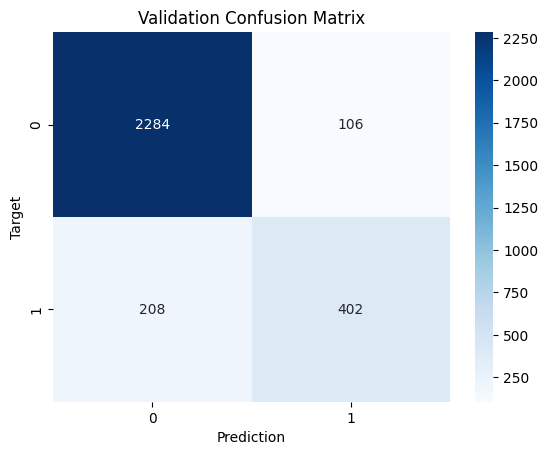

In [ ]:

numerical_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', MinMaxScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
])
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor_poly4', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear'))
])
model_pipeline_poly4.fit(train_inputs, train_target)
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_target, 'Train')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_target, 'Validation')





In [ ]:
test_raw_df = pd.read_csv(os.path.join(data_dir, 'test.csv'))


In [ ]:
test_raw_df['Exited'] = model_pipeline_poly4.predict_proba(test_raw_df[input_cols])[:, 1]


In [ ]:
test_raw_df[['id', 'Exited']].head()


,id,Exited
0,15000,0.084973
1,15001,0.025330
2,15002,0.074861
3,15003,0.377971
4,15004,0.028795


In [ ]:
# збираємо submission за зразком
submission_df = pd.read_csv(os.path.join(data_dir, 'sample_submission.csv'))
submission_df['Exited'] = test_raw_df['Exited'].values
submission_df.to_csv('submission_poly4.csv', index=False)

submission_df.head()

,id,Exited
0,15000,0.084973
1,15001,0.025330
2,15002,0.074861
3,15003,0.377971
4,15004,0.028795


Ця модель ще краще генералізує, метрики теж близькі, що означає оптимальне навчання. Сабмітимо!

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [ ]:
raw_df = pd.read_csv('regression_data.csv')

In [ ]:
raw_df


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013
...,...,...,...,...,...,...
124,1.402794,0.586857,-1.401851,0.791032,-0.909387,39.626185
125,-0.288659,-0.827231,0.322719,-1.002529,-0.018513,-50.585687
126,-1.407464,-0.213447,-0.718444,0.232050,-1.448084,13.719861
127,1.353872,1.237816,-0.114540,-0.469176,-1.713135,-23.851350


In [ ]:
train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42)

In [ ]:
X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

In [ ]:
model = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=5, include_bias=False)),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [ ]:
def evaluate(name, X, y):
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    print(f"{name:6} | R² = {r2:8.4f} | RMSE = {rmse:8.4f}")

evaluate("train", X_train, y_train)
evaluate("test",  X_test,  y_test)

train  | R² =   1.0000 | RMSE =   0.0000
test   | R² =   0.9311 | RMSE =  12.6767


Модель  хороша на тренувальному наборі, але різниця на тренувальному і тестовому наборах суттєва, це говорить про перенавчання.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [ ]:
model_lr = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

In [ ]:
model_lr.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=20, include_bias=False)),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [ ]:
def evaluate(name, X, y):
    preds = model_lr.predict(X)
    r2 = r2_score(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    print(f"{name:6} | R² = {r2:8.4f} | RMSE = {rmse:8.4f}")

evaluate("train", X_train, y_train)
evaluate("test",  X_test,  y_test)

train  | R² =   1.0000 | RMSE =   0.0000
test   | R² =  -0.8328 | RMSE =  65.3912


In [ ]:
model_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0))
])

In [ ]:
model_ridge.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=20, include_bias=False)),
                ('scaler', StandardScaler()), ('regressor', Ridge())])

In [ ]:
def evaluate(name, X, y):
    preds = model_ridge.predict(X)
    r2 = r2_score(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    print(f"{name:6} | R² = {r2:8.4f} | RMSE = {rmse:8.4f}")

evaluate("train", X_train, y_train)
evaluate("test",  X_test,  y_test)

train  | R² =   0.9994 | RMSE =   1.0537
test   | R² =   0.6688 | RMSE =  27.7976


In [ ]:
model_lasso = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(alpha=1.0))
])

In [ ]:
model_lasso.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=20, include_bias=False)),
                ('scaler', StandardScaler()), ('regressor', Lasso())])

In [ ]:
def evaluate(name, X, y):
    preds = model_lasso.predict(X)
    r2 = r2_score(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    print(f"{name:6} | R² = {r2:8.4f} | RMSE = {rmse:8.4f}")

evaluate("train", X_train, y_train)
evaluate("test",  X_test,  y_test)

train  | R² =   0.9989 | RMSE =   1.4794
test   | R² =   0.9992 | RMSE =   1.3921


In [ ]:
model_elast = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)),

])

In [ ]:
model_elast.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=20, include_bias=False)),
                ('scaler', StandardScaler()),
                ('regressor', ElasticNet(max_iter=10000))])

In [ ]:
def evaluate(name, X, y):
    preds = model_elast.predict(X)
    r2 = r2_score(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    print(f"{name:6} | R² = {r2:8.4f} | RMSE = {rmse:8.4f}")

evaluate("train", X_train, y_train)
evaluate("test",  X_test,  y_test)

train  | R² =   0.9255 | RMSE =  12.0443
test   | R² =   0.8177 | RMSE =  20.6240


In [ ]:
lasso_coefs = model_lasso.named_steps['regressor'].coef_
ridge_coefs = model_ridge.named_steps['regressor'].coef_
elast_coefs = model_elast.named_steps['regressor'].coef_


print(f"Всього ознак: {len(lasso_coefs)}")
print(f"Lasso — ненульових: {(lasso_coefs != 0).sum()}")
print(f"Ridge — ненульових: {(ridge_coefs != 0).sum()}")
print(f"Elast — ненульових: {(elast_coefs != 0).sum()}")

Всього ознак: 53129
Lasso — ненульових: 1
Ridge — ненульових: 53129
Elast — ненульових: 130


Найкраще генералізує модель з регуляризацією Lasso, бо вона занулила маже всі ознаки, залишивши тільки 1.